In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# Load Adult Census Income dataset

adult = fetch_openml('adult', version=2, as_frame=True)

df = adult.frame

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nTarget values:")
print(df['class'].value_counts())

Dataset loaded successfully!
Dataset shape: (48842, 15)

Target values:
class
<=50K    37155
>50K     11687
Name: count, dtype: int64


In [4]:
# Calculate the positive class base rate

positive_count = (df['class'] == '>50K').sum()
total_count = len(df)

base_rate = (positive_count / total_count) * 100

print("Positive class count:", positive_count)
print("Total records:", total_count)
print("Positive class base rate:", round(base_rate, 2), "%")

Positive class count: 11687
Total records: 48842
Positive class base rate: 23.93 %


Task 1: Problem Definition and  Success Metric

Target: Predict whether a person earns more than $50K per year.

Positive class: >50K
Negative class: <=50K

Business objective: Identify people who are likely to earn more than $50K and target them for marketing or outreach.
Primary metric: Precision

We choose precision because we want to minimize false positives. In this scenario, contacting people who are unlikely to earn more than $50K can waste marketing resources. A high precision means that most people identified as positive actually belong to the >50K income group.

Class base rate: Approximately 23.93% of people in the dataset belong to the positive class (>50K).

In [ ]:
# Task 2: Convert target into binary (0 = <=50K, 1 = >50K)

df['income'] = (df['class'] == '>50K').astype(int)

print(df['income'].value_counts())

# Convert missing values to NaN

df = df.replace('?', np.nan)

print("\nMissing values in each column:")
print(df.isnull().sum())
# Check data shape and column types

print("Dataset shape:", df.shape)
print("\nColumn data types:")
print(df.dtypes)

# Numeric summary

print(df.describe())
# Task 2: Value counts for categorical columns

categorical_columns = df.select_dtypes(include=['category', 'object']).columns


print("Categorical columns:")
print(categorical_columns)



income
0    37155
1    11687
Name: count, dtype: int64

Missing values in each column:
age                  0
workclass         2799
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
income               0
dtype: int64
Dataset shape: (48842, 16)

Column data types:
age                  int64
workclass         category
fnlwgt               int64
education         category
education-num        int64
marital-status    category
occupation        category
relationship      category
race              category
sex               category
capital-gain         int64
capital-loss         int64
hours-per-week       int64
native-country    category
class             category
income               int64
dtype: object
                age        fnlwgt  educ

In [ ]:
# Value counts for categorical features

print("Education:")
print(df['education'].value_counts())

print("\nSex:")
print(df['sex'].value_counts())

print("\nWorkclass:")
print(df['workclass'].value_counts(dropna=False))

Education:
education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

Sex:
sex
Male      32650
Female    16192
Name: count, dtype: int64

Workclass:
workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
NaN                  2799
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64


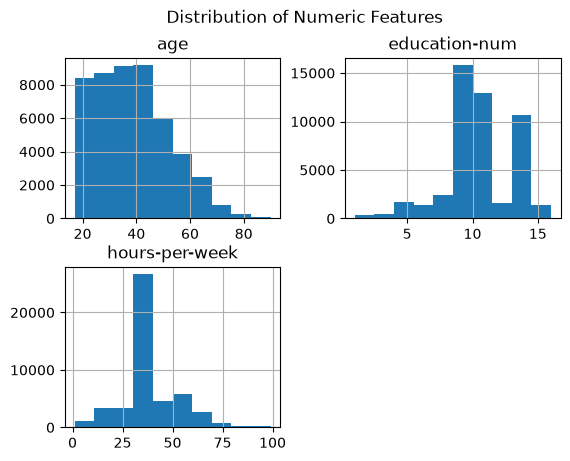

In [16]:
# Task 2: Histograms

df[['age', 'education-num', 'hours-per-week']].hist()

plt.suptitle("Distribution of Numeric Features")
plt.show()

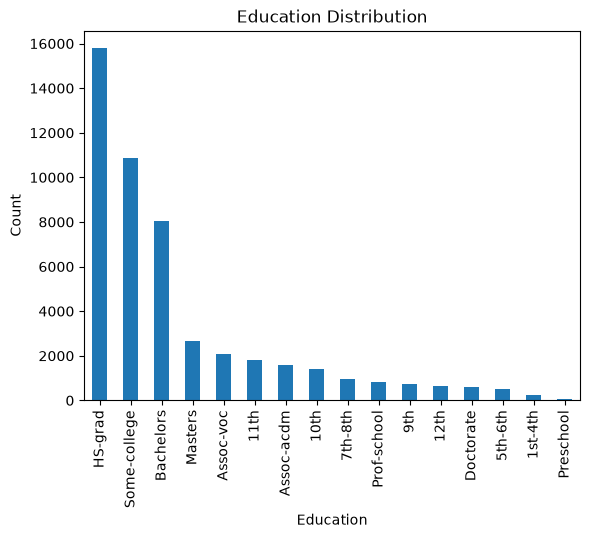

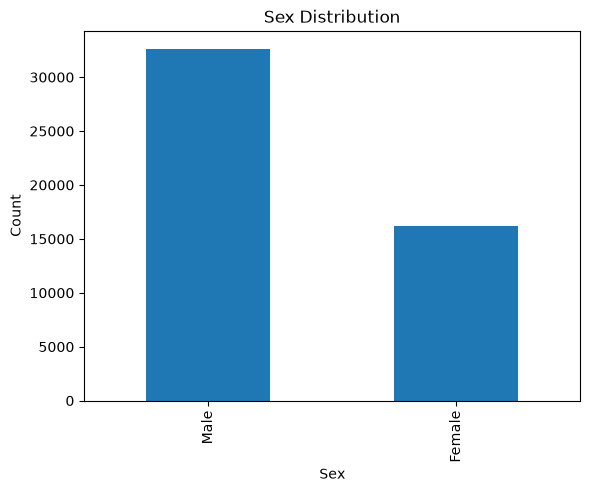

In [17]:
# Task 2: Bar plots

df['education'].value_counts().plot(kind='bar')
plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.show()
# for sex
df['sex'].value_counts().plot(kind='bar')
plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

In [19]:
# Task 2: Summary table

summary = pd.DataFrame({
    'Feature': ['Income <=50K', 'Income >50K', 'Age', 'Hours-per-week'],
    'Summary': [
        (df['income'] == 0).sum(),
        (df['income'] == 1).sum(),
        df['age'].mean(),
        df['hours-per-week'].mean()
    ]
})

print(summary)

          Feature       Summary
0    Income <=50K  37155.000000
1     Income >50K  11687.000000
2             Age     38.643585
3  Hours-per-week     40.422382


In [22]:
# Task 3: Split data into training and testing

X = df.drop('income', axis=1)
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data:", X_train.shape)
print("Test data:", X_test.shape)

Training data: (39073, 15)
Test data: (9769, 15)


 Why Hold-out Test is Necessary

We keep some data separate to test the model on new data.
We should not use this data while training or tuning the model because it can give us a wrong idea of how good the model really is.

In [24]:
# Task 4: Majority class baseline

majority_prediction = 0

y_pred_majority = np.full(len(y_test), majority_prediction)

print("Majority class prediction:", majority_prediction)

# Rule-based baseline

y_pred_rule = (X_test['education-num'] >= 13).astype(int)

Majority class prediction: 0


In [30]:
# Majority baseline metrics

print("Accuracy:", accuracy_score(y_test, y_pred_majority))
print("Precision:", precision_score(y_test, y_pred_majority, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_majority, zero_division=0))
print("F1:", f1_score(y_test, y_pred_majority, zero_division=0))
print("ROC AUC:", roc_auc_score(y_test, y_pred_majority))
print("PR AUC:", average_precision_score(y_test, y_pred_majority))

# Rule-based baseline metrics

print("Accuracy:", accuracy_score(y_test, y_pred_rule))
print("Precision:", precision_score(y_test, y_pred_rule, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_rule, zero_division=0))
print("F1:", f1_score(y_test, y_pred_rule, zero_division=0))
# ROC AUC and PR AUC

print("Rule-based ROC AUC:", roc_auc_score(y_test, y_pred_rule))
print("Rule-based PR AUC:", average_precision_score(y_test, y_pred_rule))

Accuracy: 0.7606715119254785
Precision: 0.0
Recall: 0.0
F1: 0.0
ROC AUC: 0.5
PR AUC: 0.23932848807452145
Accuracy: 0.7529941652165012
Precision: 0.484368486869529
Recall: 0.49700598802395207
F1: 0.4906058686932658
Rule-based ROC AUC: 0.6652705892212346
Rule-based PR AUC: 0.3611148347810222


In [31]:
# Confusion matrix for majority baseline

cm_majority = confusion_matrix(y_test, y_pred_majority)

print(cm_majority)
# Confusion matrix for rule-based baseline

cm_rule = confusion_matrix(y_test, y_pred_rule)

print(cm_rule)


[[7431    0]
 [2338    0]]
[[6194 1237]
 [1176 1162]]


In [32]:
# Task 5: False positives and false negatives

false_positives = X_test[(y_test == 0) & (y_pred_rule == 1)]
false_negatives = X_test[(y_test == 1) & (y_pred_rule == 0)]

print("False Positives:")
print(false_positives.head(10))

print("\nFalse Negatives:")
print(false_negatives.head(10))

False Positives:
       age         workclass  fnlwgt  education  education-num  \
38546   42           Private  269028  Doctorate             16   
18199   25         Local-gov  125863  Bachelors             13   
2271    24      Self-emp-inc  197496  Bachelors             13   
35730   37           Private  225504    Masters             14   
44616   35           Private  198341  Bachelors             13   
7541    23           Private  107882  Bachelors             13   
42512   26           Private   29957    Masters             14   
5805    53           Private  107096  Bachelors             13   
36308   40           Private  105936  Bachelors             13   
38118   40  Self-emp-not-inc  282678    Masters             14   

           marital-status       occupation    relationship  \
38546  Married-civ-spouse   Prof-specialty         Husband   
18199       Never-married   Prof-specialty       Own-child   
2271        Never-married     Adm-clerical       Own-child   
35730   

In [34]:
# Check some patterns

print("False Positive Age:")
print(false_positives['age'].head(10))

print("\nFalse Negative Age:")
print(false_negatives['age'].head(10))

print("\nFalse Positive Hours:")
print(false_positives['hours-per-week'].head(10))

print("\nFalse Negative Hours:")
print(false_negatives['hours-per-week'].head(10))

False Positive Age:
38546    42
18199    25
2271     24
35730    37
44616    35
7541     23
42512    26
5805     53
36308    40
38118    40
Name: age, dtype: int64

False Negative Age:
31692    47
11488    38
33956    68
45549    26
9863     56
30035    42
29836    43
41420    50
17615    51
32445    57
Name: age, dtype: int64

False Positive Hours:
38546    40
18199    35
2271     20
35730    50
44616    40
7541     50
42512    25
5805     50
36308    40
38118    20
Name: hours-per-week, dtype: int64

False Negative Hours:
31692    40
11488    40
33956    40
45549    55
9863     54
30035    40
29836    50
41420    38
17615    40
32445    50
Name: hours-per-week, dtype: int64


 Data and Feature Issues to Fix 

1. Handle missing values.
2. Convert categorical columns into numbers.
4. Check extreme values.
5. Select useful features for the model.
6. Reduce false positives and false negatives with better features and a better model.

 Primary Metric

I will use Precision as the main metric for the rest of the week.
The majority baseline has 0 precision, while the rule-based baseline has about 48% precision. I want to improve precision so that when the model predicts >50K, the prediction is more likely to be correct.